# Appliance Consumption Signatures
### Task:
    - build a classification model that can accurately predict the class appliance based on their power consumption

In [2]:
pip install numpy pandas matplotlib scipy scikit-learn

  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [sci


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Data Engineering

In [3]:
import pandas as pd
import numpy as np


ts = pd.read_csv("../data/train.csv",  header=None)
ts.columns = ["class"] + [f"t{i}" for i in range(len(ts.columns) - 1)] # rename columns
ts.head()

,class,t0,t1,t2,t3,t4,t5,t6,t7,t8,...,t1450,t1451,t1452,t1453,t1454,t1455,t1456,t1457,t1458,t1459
0,9,-0.584754,-0.584754,1.730991,-0.584754,-0.584754,-0.584754,1.729917,-0.584754,-0.584754,...,1.732726,-0.584734,-0.583729,-0.578603,1.732726,-0.584734,-0.583729,-0.578603,1.732726,-0.584734
1,9,-0.591434,-0.511104,1.726820,-0.580422,-0.591434,-0.511104,1.727921,-0.580422,-0.591434,...,1.727396,-0.580731,-0.580731,-0.580731,1.727396,-0.580731,-0.580731,-0.580731,1.727396,-0.580731
2,9,-0.577945,-0.577945,1.730793,-0.577945,-0.578946,-0.564882,1.731094,-0.577829,-0.580956,...,1.734727,-0.577751,-0.580956,-0.549798,1.734727,-0.577751,-0.580956,-0.549798,1.734727,-0.577751
3,9,-0.588925,-0.538088,1.735718,-0.588716,-0.589962,-0.523551,1.735619,-0.588646,-0.588925,...,1.743664,-0.588876,-0.586852,-0.576483,1.743664,-0.588876,-0.586852,-0.576483,1.743664,-0.588876
4,9,-0.596633,-0.532188,1.718067,-0.592117,-0.596633,-0.532188,1.715241,-0.592117,-0.595605,...,1.743258,-0.592403,-0.591524,-0.575158,1.743258,-0.592403,-0.591524,-0.575158,1.743258,-0.592403


#### Class Distribution

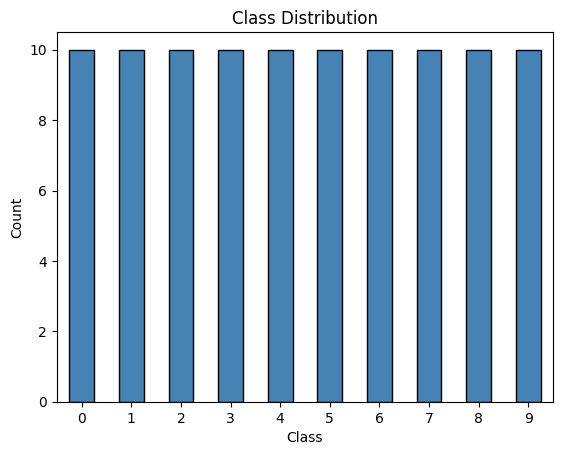

In [4]:
import matplotlib.pyplot as plt

ts["class"].value_counts().sort_index().plot(kind="bar", color="steelblue", edgecolor="black")
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.xticks(rotation=0)
plt.show()

#### Time Series graph

In [ ]:
classes = sorted(ts["class"].unique())
fig, axes = plt.subplots(len(classes), 1, figsize=(12, 3 * len(classes)), sharex=True)

for ax, cls in zip(axes, classes):
    row = ts[ts["class"] == cls].sample(1).iloc[0]
    time_cols = [c for c in ts.columns if c != "class"]
    ax.plot(time_cols, row[time_cols].values, linewidth=0.7)
    ax.set_title(f"Class {cls}")
    
plt.tight_layout()
plt.show()

In [19]:
from scipy import stats
from scipy.signal import find_peaks

time_cols = [c for c in ts.columns if c != "class"]
series_matrix = ts[time_cols].values  # shape (n_samples, n_timesteps)
features = {}

def compute_features(row):
    x = row
    n = len(x)
    out = {}
    
    out["mean"] = np.mean(x)
    out["std"] = np.std(x, ddof=0)
    out["min"] = np.min(x)
    out["max"] = np.max(x)
    out["median"] = np.median(x)
    out["skewness"] = stats.skew(x)
    out["kurtosis"] = stats.kurtosis(x)
    out["q25"] = np.percentile(x, 25)
    out["q75"] = np.percentile(x, 75)
    out["iqr"] = out["q75"] - out["q25"]
    out["energy"] = np.sum(x ** 2)
    out["rms"] = np.sqrt(np.mean(x ** 2))
    out["abs_mean"] = np.mean(np.abs(x))
    xc = x - out["mean"]
    out["zero_crossing_rate"] = np.sum(np.diff(np.sign(xc)) != 0) / n
    dx = np.diff(x)
    out["mean_abs_change"] = np.mean(np.abs(dx))
    out["std_change"] = np.std(dx, ddof=0)
    peaks, _ = find_peaks(x)
    out["num_peaks"] = len(peaks)
    out["mean_peak_height"] = np.mean(x[peaks]) if len(peaks) > 0 else 0.0
    fft_vals = np.abs(np.fft.rfft(x))
    fft_vals_normed = fft_vals / fft_vals.sum()
    out["dominant_freq"] = np.argmax(fft_vals) / len(fft_vals)
    out["spectral_energy"] = np.sum(fft_vals ** 2)
    mid = len(fft_vals) // 2
    out["low_band_energy"] = np.sum(fft_vals[:mid] ** 2)
    out["high_band_energy"] = np.sum(fft_vals[mid:] ** 2)
    out["spectral_entropy"] = stats.entropy(fft_vals_normed)
    return out

records = [compute_features(series_matrix[i]) for i in range(len(series_matrix))]
ts_meaningful = pd.DataFrame(records)
ts_meaningful.insert(0, "class", ts["class"].values)
ts_meaningful.head()

,class,mean,std,min,max,median,skewness,kurtosis,q25,q75,...,zero_crossing_rate,mean_abs_change,std_change,num_peaks,mean_peak_height,dominant_freq,spectral_energy,low_band_energy,high_band_energy,spectral_entropy
0,9,4.383562e-10,1.0,-0.591929,1.747964,-0.583729,1.154184,-0.666973,-0.584704,0.037462,...,0.5,1.159583,1.630717,365,1.731903,0.499316,1.416126e+06,40.222365,1.416086e+06,1.194067
1,9,-6.986302e-10,1.0,-0.591434,1.745335,-0.580731,1.154224,-0.666973,-0.580731,0.044242,...,0.5,1.157709,1.631896,365,1.731917,0.499316,1.418172e+06,71.039092,1.418101e+06,1.260163
2,9,-8.904122e-11,1.0,-0.580956,1.740127,-0.577945,1.154660,-0.666677,-0.577945,0.019835,...,0.5,1.155887,1.633264,365,1.732037,0.499316,1.420564e+06,7.379814,1.420556e+06,1.002905
3,9,1.404110e-09,1.0,-0.589962,1.746456,-0.583741,1.153912,-0.667159,-0.588706,0.035436,...,0.5,1.161135,1.630030,365,1.731830,0.499316,1.414932e+06,28.489575,1.414904e+06,1.200142
4,9,-6.849318e-11,1.0,-0.596633,1.745156,-0.582827,1.153159,-0.667817,-0.592285,0.030440,...,0.5,1.163967,1.627424,365,1.731651,0.499316,1.410398e+06,25.023863,1.410373e+06,1.094086


#### Modeling

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, accuracy_score
X = ts_meaningful.drop(columns=["class"]).values
y = ts_meaningful["class"].values
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(sss.split(X, y))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

ModuleNotFoundError: No module named 'sklearn'